In [36]:
%load_ext autoreload
%autoreload 2
    
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
from copy import deepcopy
import lbm_suite2p_python as lsp

import matplotlib as mpl
mpl.rcParams.update({
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'figure.subplot.wspace': .01,
    'figure.subplot.hspace': .01,
    'figure.figsize': (18, 13),
    'ytick.major.left': True,
})
jet = mpl.cm.get_cmap('jet')
jet.set_bad(color='k')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
mk303 = Path(r"D:\W2_DATA\kbarber\2025-02-10\mk303")
assembled_path = mk303.joinpath("assembled")
save_path = mk303.joinpath("results")  # where the z-plane tiff files live
print(f"Saving raw tiffs to:        {assembled_path}")
print(f"Saving suite2p results to:  {save_path}")

Saving raw tiffs to:        D:\W2_DATA\kbarber\2025-02-10\mk303\assembled
Saving suite2p results to:  D:\W2_DATA\kbarber\2025-02-10\mk303\results


In [17]:
input_files = mbo.get_files(assembled_path, str_contains='tif', max_depth=3)
input_files = [Path(x) for x in input_files]
input_files[:3]

[WindowsPath('D:/W2_DATA/kbarber/2025-02-10/mk303/assembled/plane_01_demo.tiff'),
 WindowsPath('D:/W2_DATA/kbarber/2025-02-10/mk303/assembled/plane_02_demo.tiff'),
 WindowsPath('D:/W2_DATA/kbarber/2025-02-10/mk303/assembled/plane_03_demo.tiff')]

In [20]:
input_files[9]

WindowsPath('D:/W2_DATA/kbarber/2025-02-10/mk303/assembled/plane_10_demo.tiff')

In [30]:
from itertools import product

scaling_variants = [0.25, 0.5, 2, 6]
overlap_variants = [0.5, 0.65, 0.9]
parameter_grid = list(product(scaling_variants, overlap_variants))

base_dir = save_path.parent / 'grid_search'
base_dir.mkdir(exist_ok=True)

mdata = mbo.get_metadata(input_files[0])
ops = mbo.params_from_metadata(mdata, suite2p.default_ops())
ops['tiff_list'] = [str(input_files[9])]

Ops provided. Setting pipeline to suite2p


In [ ]:
from copy import deepcopy

for scaling, overlap in parameter_grid:
    dir_name = f"thrscale_{scaling}_overlap_{overlap}".replace(".", "_")
    path = base_dir.joinpath(dir_name)
    path.mkdir(exist_ok=True)
    new_ops = deepcopy(ops)
    new_ops['threshold_scaling'] = scaling
    new_ops['max_overlap'] = overlap
    ops['save_path0'] = str(path)

    # opsEnd=suite2p.run_s2p(ops=new_ops,db={'data_path': [str(input_files[9].parent)], 'save_path': [path]})

In [34]:
ops_files = mbo.get_files(base_dir, 'ops', 4)
ops_files

['D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_0_25_overlap_0_5\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_0_25_overlap_0_65\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_0_25_overlap_0_9\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_0_5_overlap_0_5\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_0_5_overlap_0_65\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_0_5_overlap_0_9\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_2_overlap_0_5\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_2_overlap_0_65\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbarber\\2025-02-10\\mk303\\grid_search\\thrscale_2_overlap_0_9\\suite2p\\plane0\\ops.npy',
 'D:\\W2_DATA\\kbar

Post processing started.


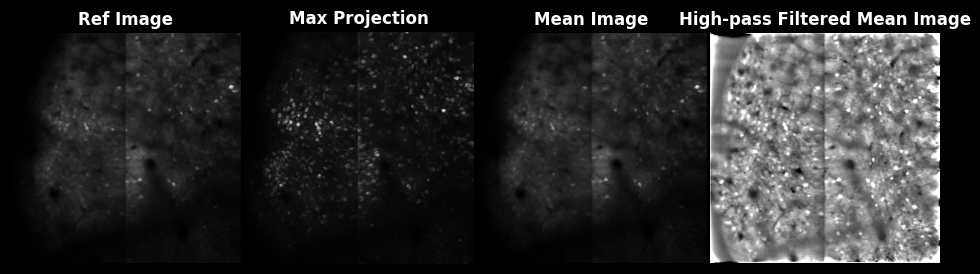

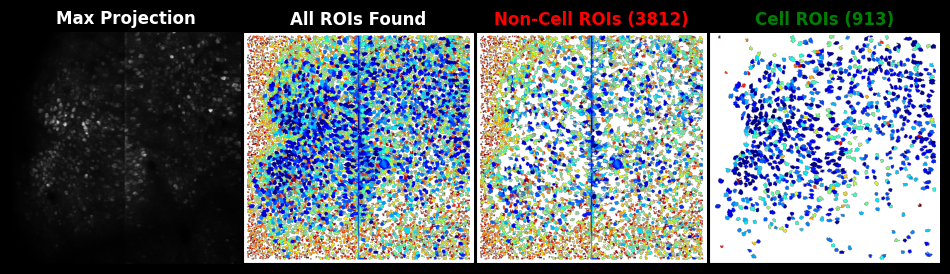

Post processing started.


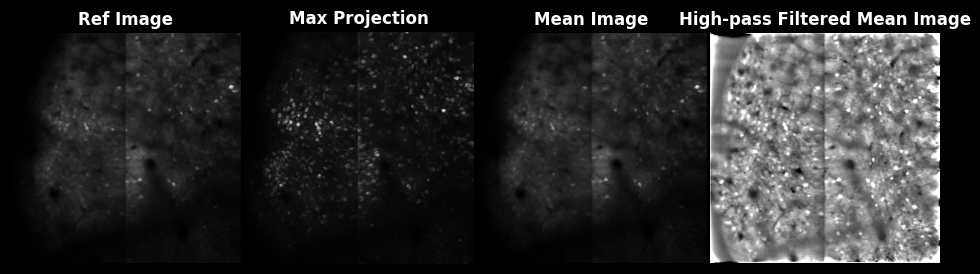

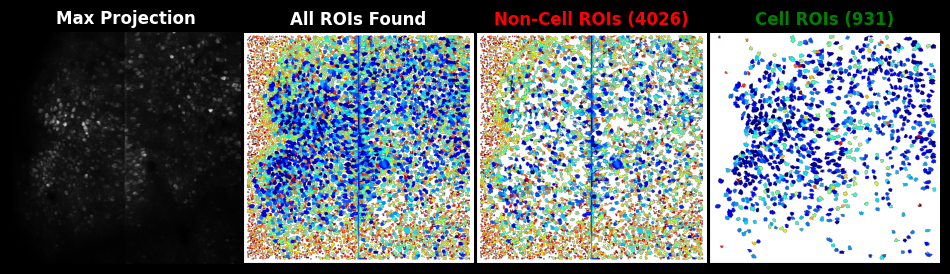

Post processing started.


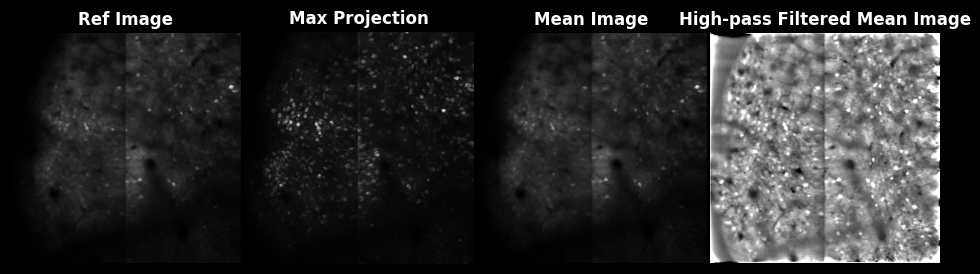

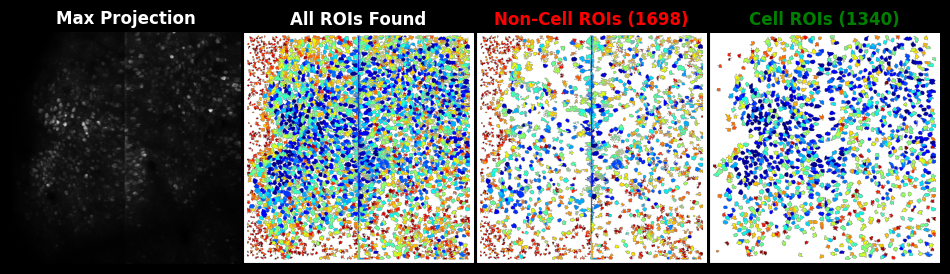

Post processing started.


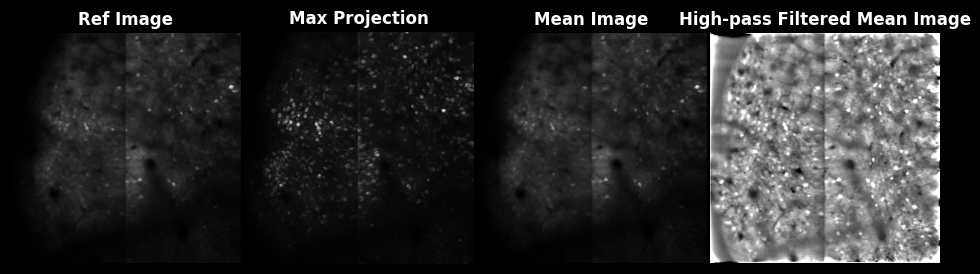

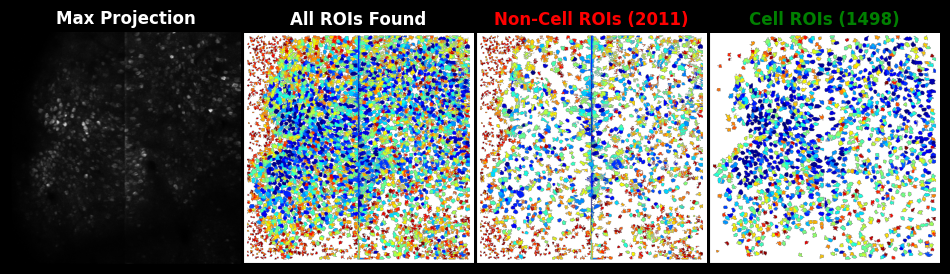

Post processing started.


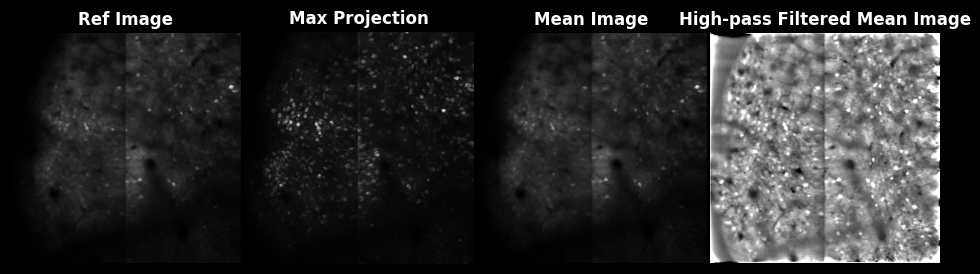

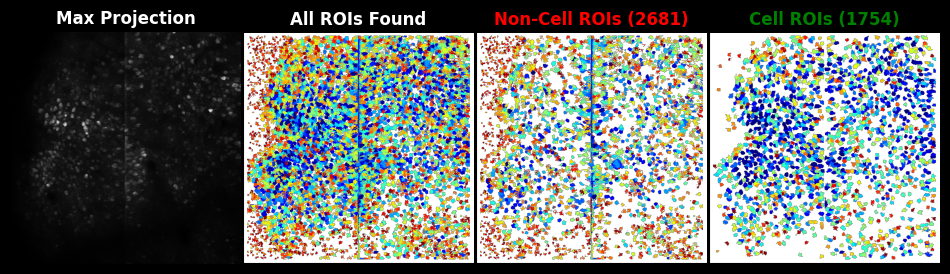

Post processing started.


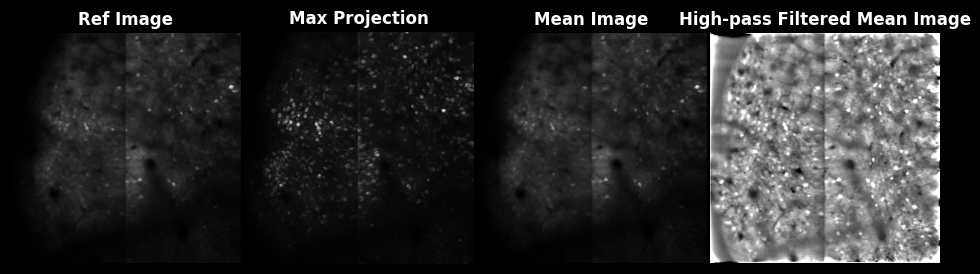

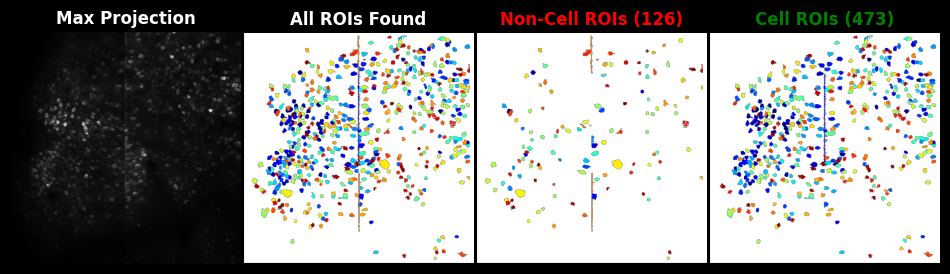

Post processing started.


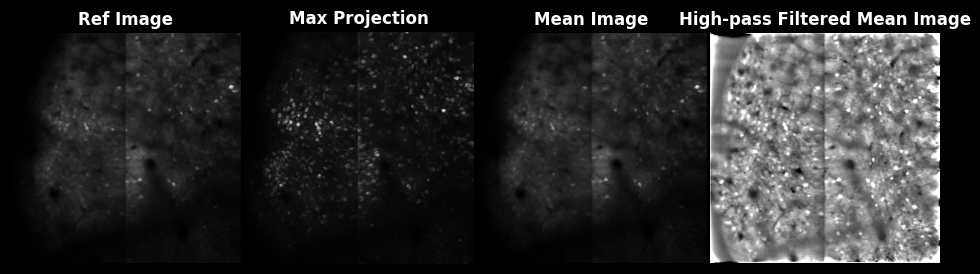

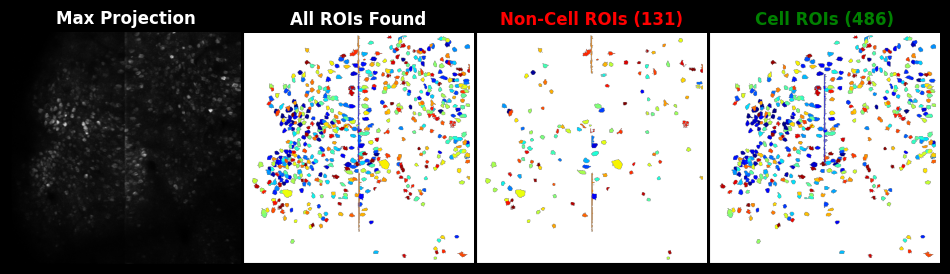

Post processing started.


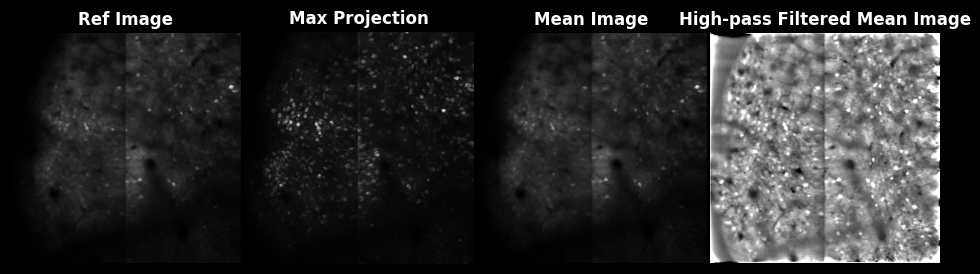

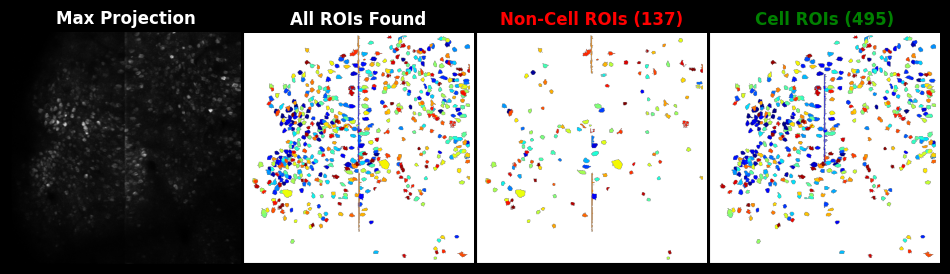

Post processing started.


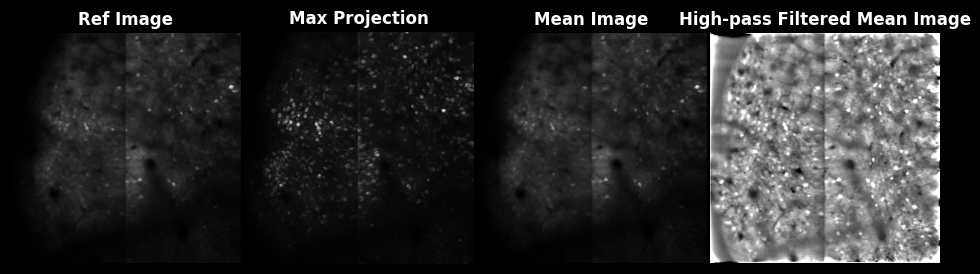

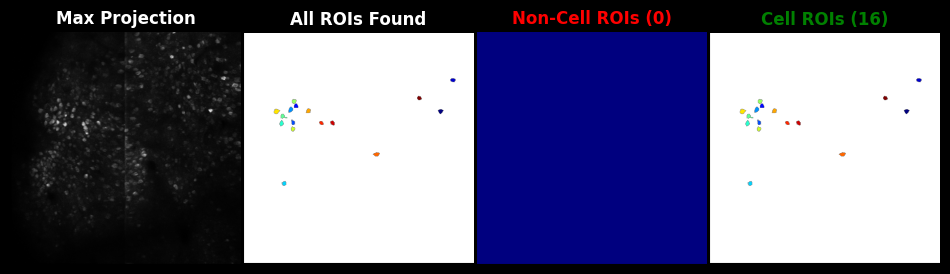

Post processing started.


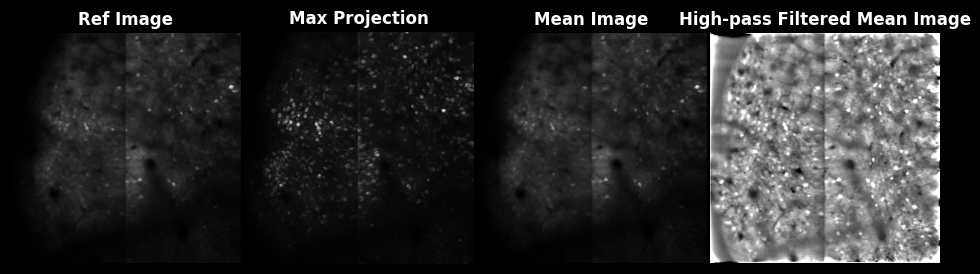

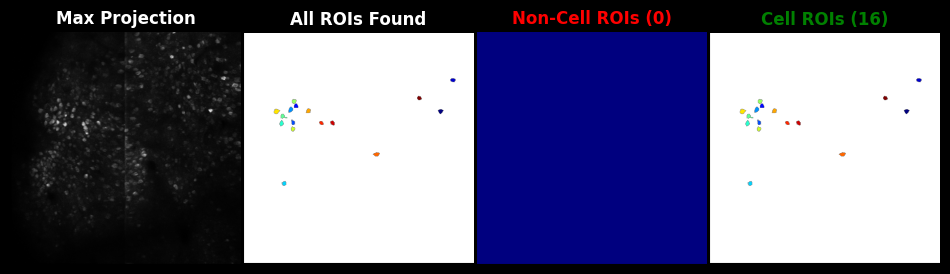

Post processing started.


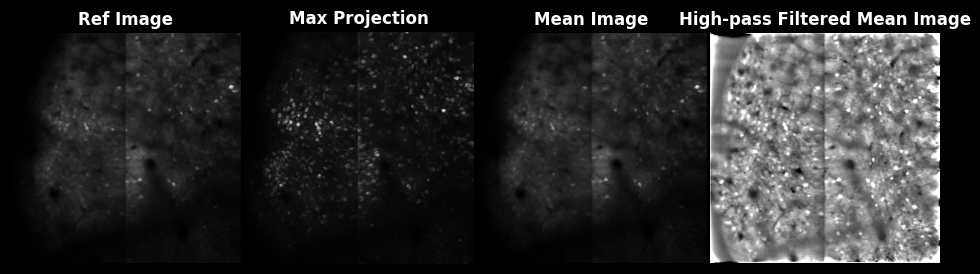

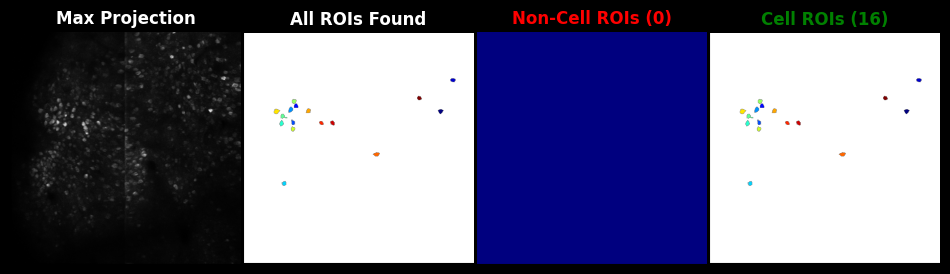

In [43]:
for op in ops_files:
    lsp.post_process(op, overwrite=True)

In [ ]:
zstats_file = get_volume_stats(ops_files, overwrite=True)

plot_volume_stats(zstats_file, os.path.join(save_path, "acc_rej_bar.png"))
plot_volume_signal(zstats_file, os.path.join(save_path, "mean_volume_signal.png"))
plot_roi_maps(all_ops, os.path.join(save_path, "max_cell_noncell.png"))
plot_execution_time(zstats_file, os.path.join(save_path, "execution_time.png"))

fcells_list = get_fcells_list(all_ops)
flourescence_savepath = os.path.join(save_path, "flourescence.png")
plot_fluorescence_grid_auto(fcells_list, flourescence_savepath)